# GPT Solutions step by step

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

base_path = r"../playground-series-s5e11/"

train = pd.read_csv(base_path + "train.csv")
test = pd.read_csv(base_path + "test.csv")

train_org = train.copy()
test_org = test.copy()

print("✅ Train shape:", train.shape)
print("✅ Test shape:", test.shape)

print("\n🔍 Train columns:\n", train.columns.tolist())
print("\n🔍 First few rows of train:")
display(train.head())

print("\n📋 Data types:")
print(train.dtypes)


✅ Train shape: (593994, 13)
✅ Test shape: (254569, 12)

🔍 Train columns:
 ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_paid_back']

🔍 First few rows of train:


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0



📋 Data types:
id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                   object
marital_status           object
education_level          object
employment_status        object
loan_purpose             object
grade_subgrade           object
loan_paid_back          float64
dtype: object


In [13]:
# Missing values summary
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("🔍 Missing values per column:\n", missing)

# Duplicates
print("\n🧱 Duplicate rows:", train.duplicated().sum())

# Unique counts for categorical variables
cat_cols = train.select_dtypes(include="object").columns
print("\n🧩 Unique values in categorical columns:")
for col in cat_cols:
    print(f"{col}: {train[col].nunique()} unique values")


🔍 Missing values per column:
 Series([], dtype: int64)

🧱 Duplicate rows: 0

🧩 Unique values in categorical columns:
gender: 3 unique values
marital_status: 4 unique values
education_level: 5 unique values
employment_status: 5 unique values
loan_purpose: 8 unique values
grade_subgrade: 30 unique values


<Axes: xlabel='loan_paid_back', ylabel='count'>

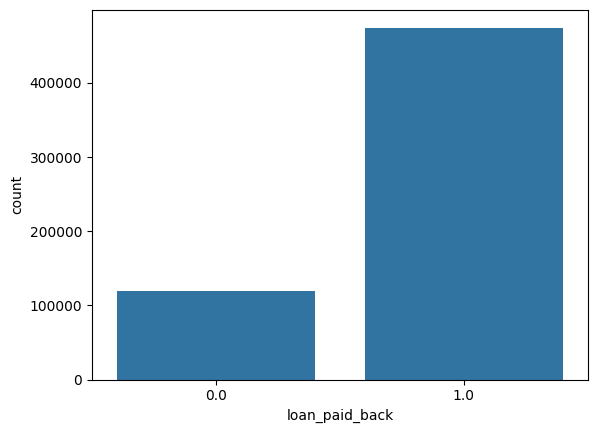

In [14]:
import seaborn as sns
sns.countplot(x='loan_paid_back', data=train)

In [15]:
train.describe().T


,count,mean,std,min,25%,50%,75%,max
id,593994.0,296996.500000,171471.442236,0.000,148498.250,296996.500,445494.750,593993.000
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


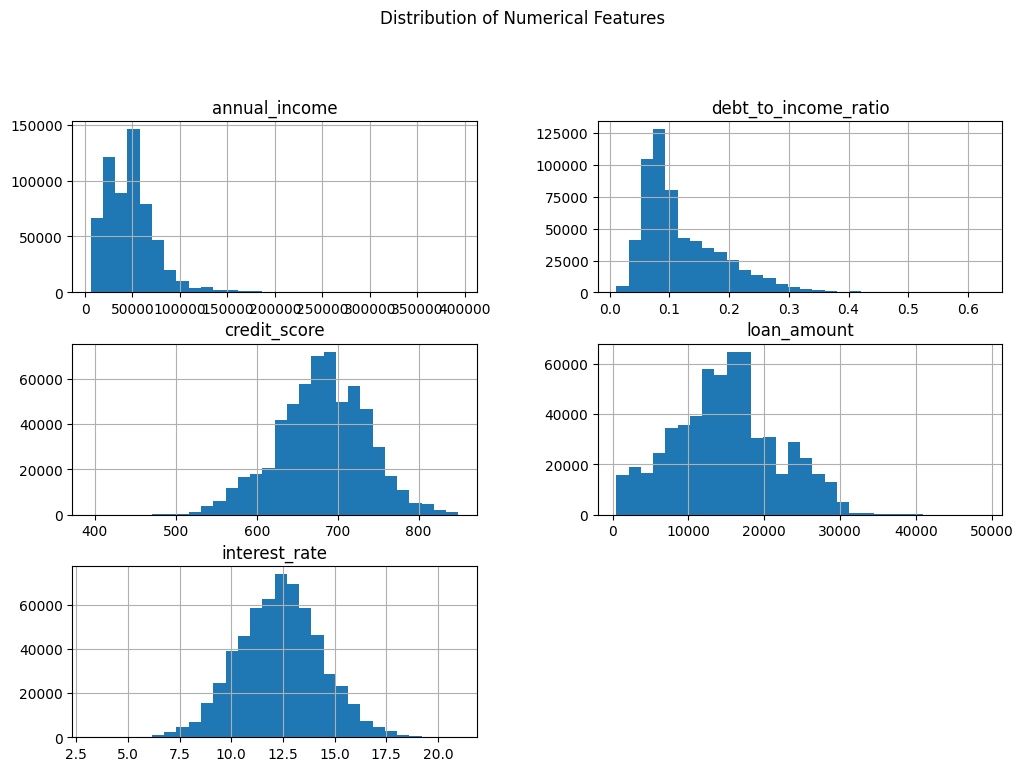

In [16]:
numeric_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
train[numeric_cols].hist(bins=30, figsize=(12,8))
plt.suptitle("Distribution of Numerical Features", y=1.02)
plt.show()

In [17]:
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for c in cat_cols:
    print(f"\n{c} value counts:")
    print(train[c].value_counts(normalize=True))



gender value counts:
gender
Female    0.515451
Male      0.478273
Other     0.006276
Name: proportion, dtype: float64

marital_status value counts:
marital_status
Single      0.486273
Married     0.466737
Divorced    0.035879
Widowed     0.011111
Name: proportion, dtype: float64

education_level value counts:
education_level
Bachelor's     0.470722
High School    0.309081
Master's       0.156731
Other          0.044911
PhD            0.018556
Name: proportion, dtype: float64

employment_status value counts:
employment_status
Employed         0.758669
Unemployed       0.105195
Self-employed    0.088351
Retired          0.027699
Student          0.020086
Name: proportion, dtype: float64

loan_purpose value counts:
loan_purpose
Debt consolidation    0.546630
Other                 0.107533
Car                   0.097826
Home                  0.074273
Education             0.061686
Business              0.059433
Medical               0.038394
Vacation              0.014224
Name: proportion

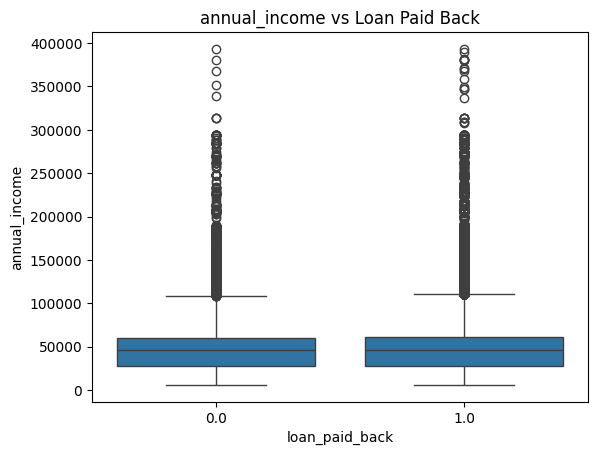

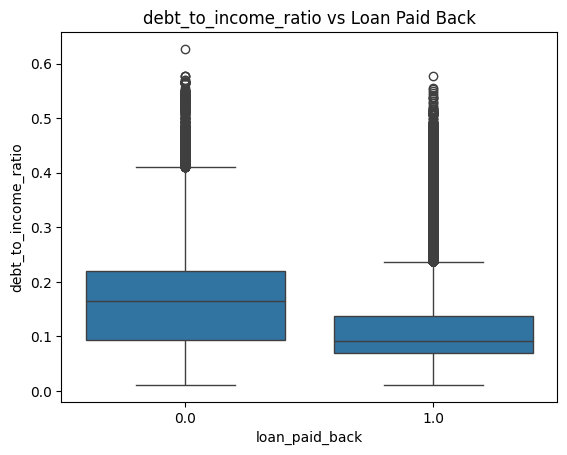

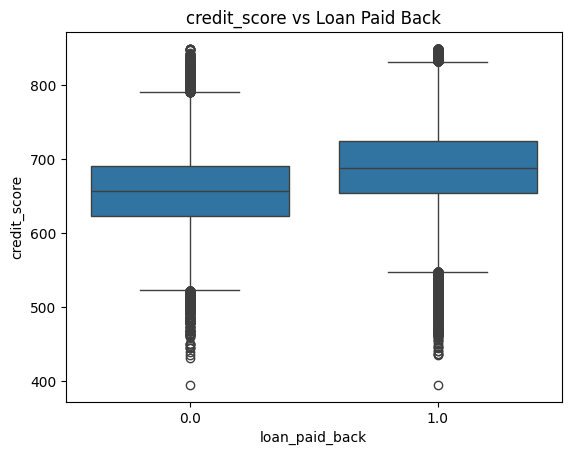

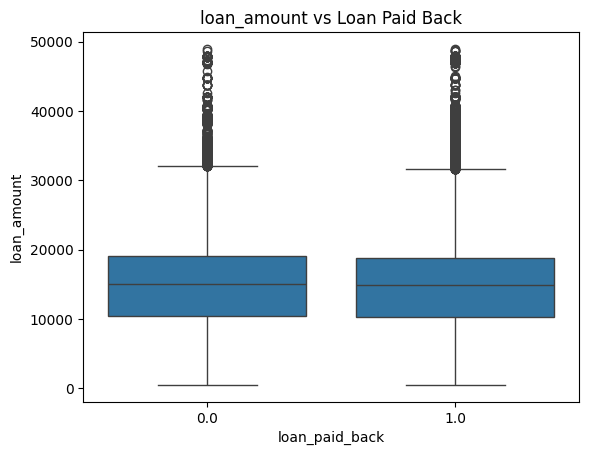

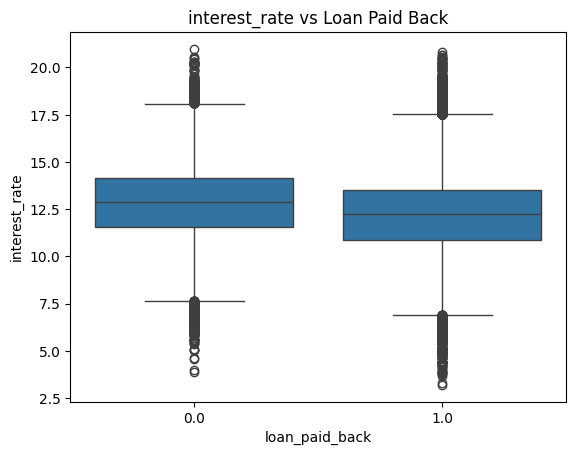

In [18]:
# Step 5.1: Bivariate Analysis (Target Relationships) Numeric
for c in numeric_cols:
    sns.boxplot(x='loan_paid_back', y=c, data=train)
    plt.title(f"{c} vs Loan Paid Back")
    plt.show()

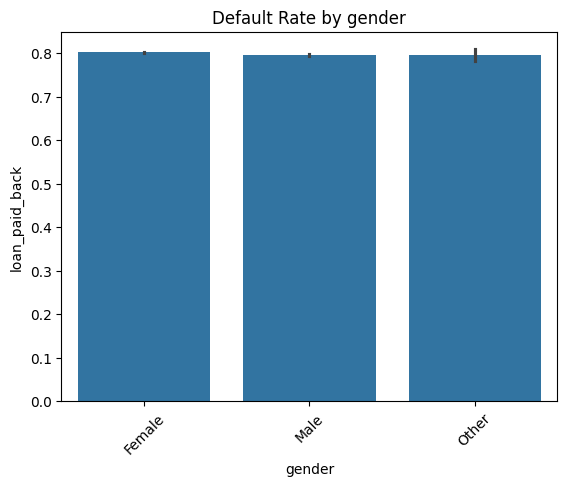

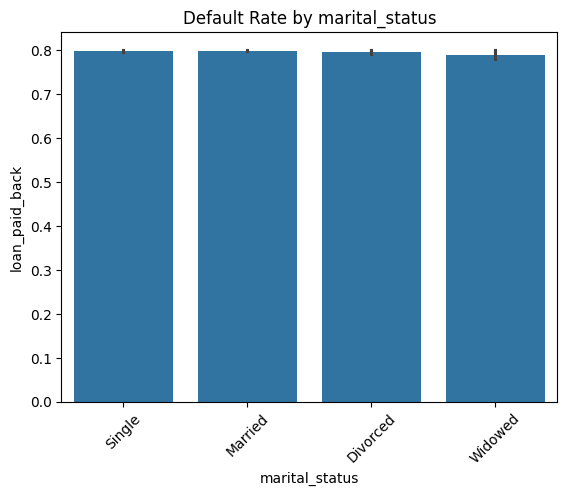

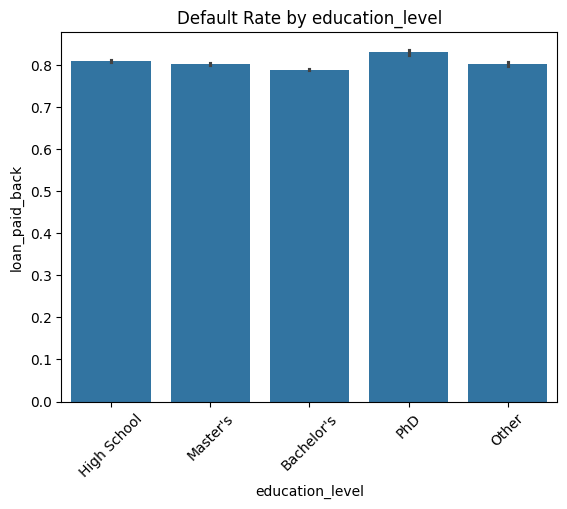

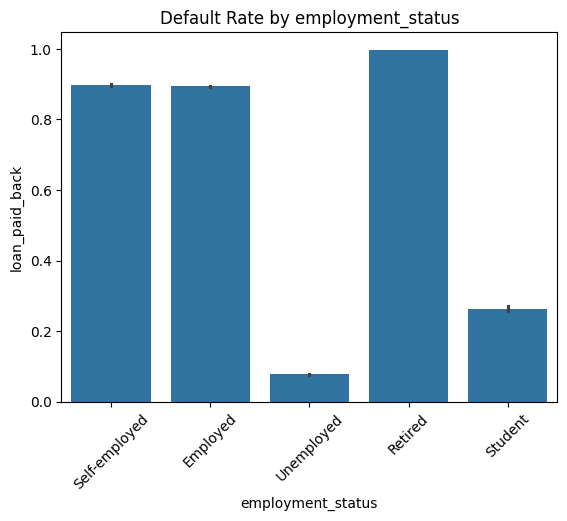

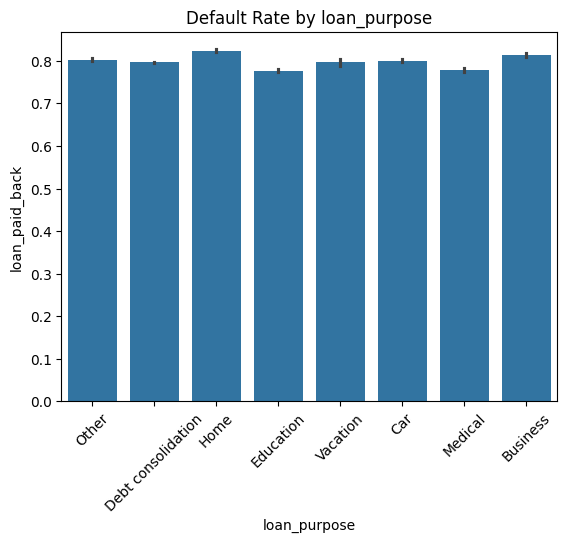

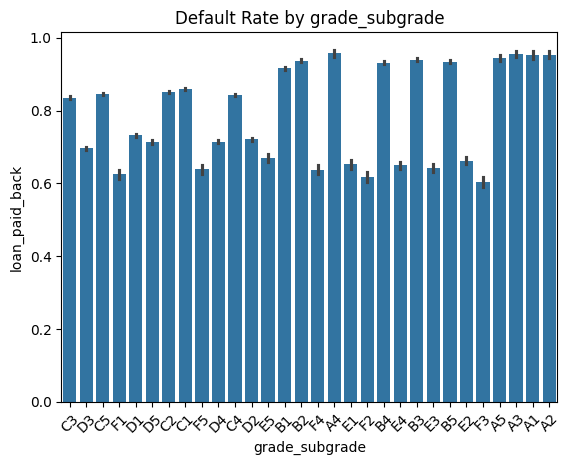

In [19]:
import numpy as np
# Step 5.2: Bivariate Analysis (Target Relationships) Categorical
for c in cat_cols:
    sns.barplot(x=c, y='loan_paid_back', data=train, estimator=np.mean)
    plt.title(f"Default Rate by {c}")
    plt.xticks(rotation=45)
    plt.show()

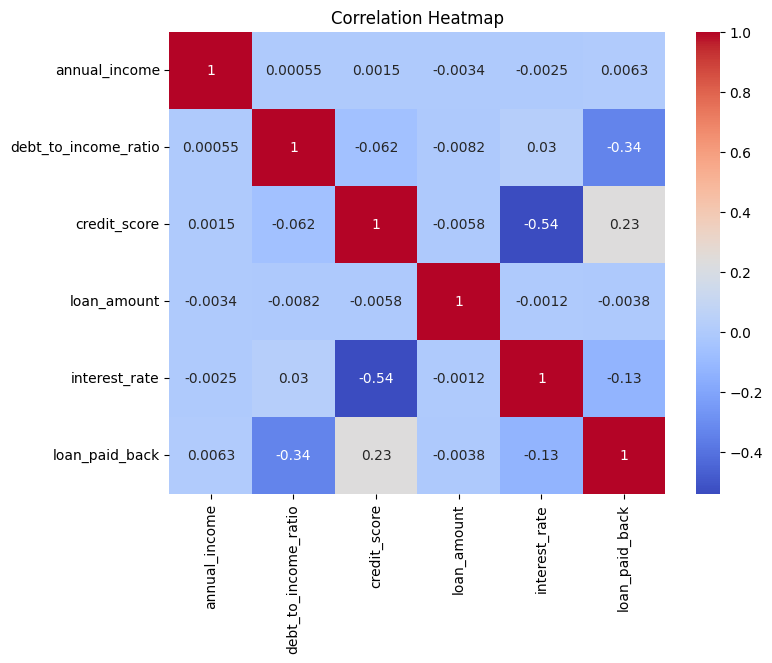

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(train[numeric_cols + ['loan_paid_back']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


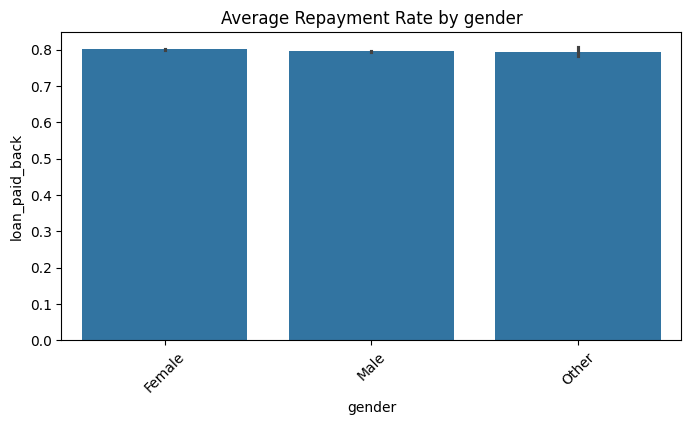

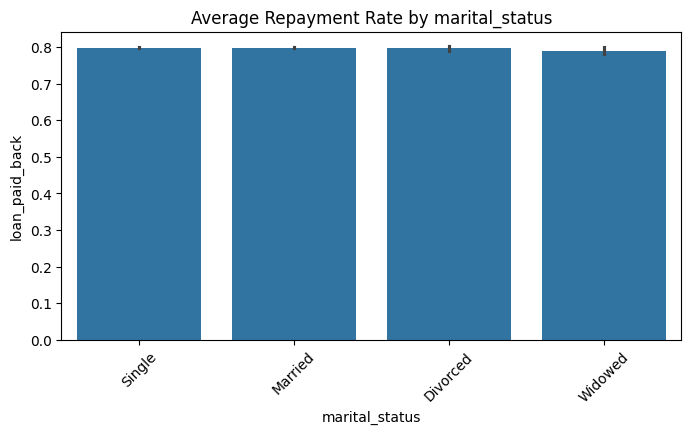

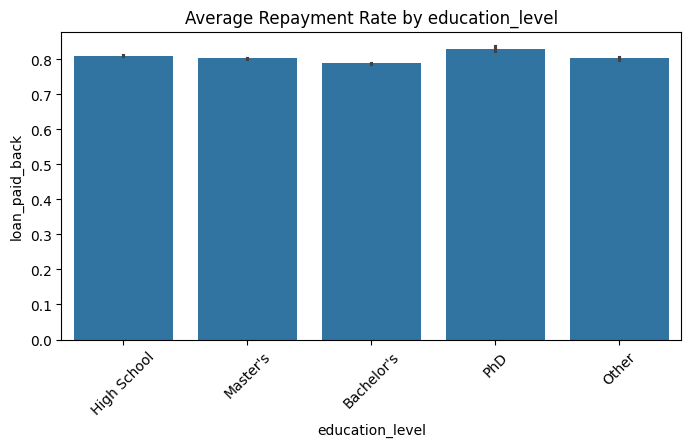

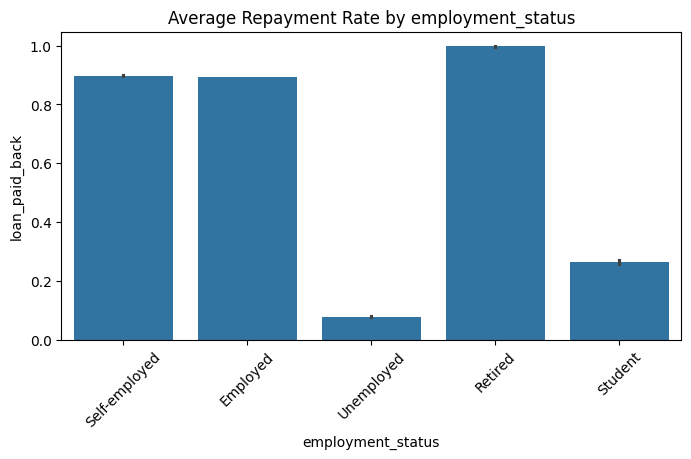

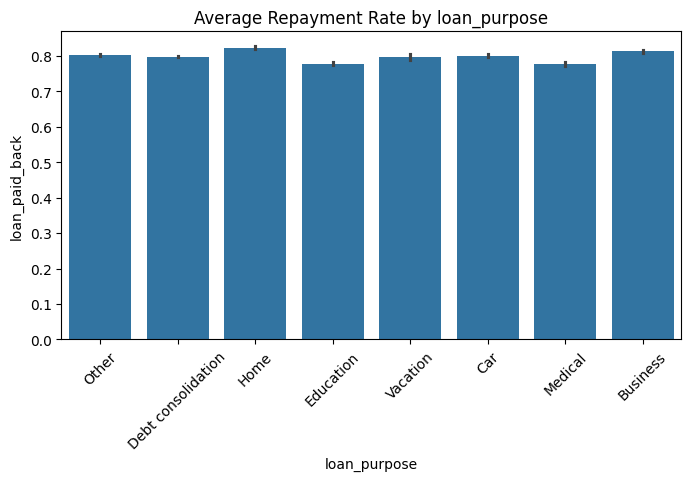

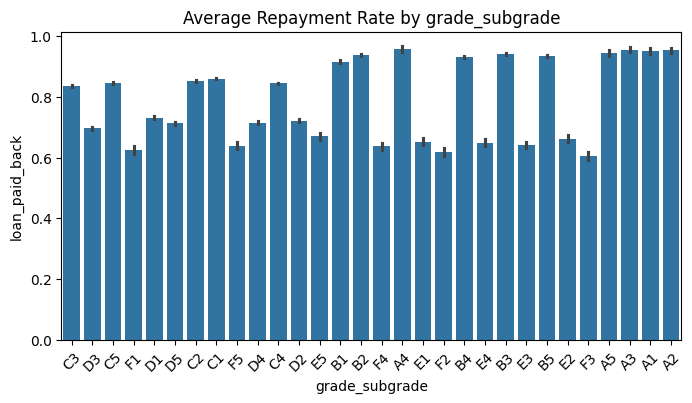

In [21]:
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for c in cat_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=c, y='loan_paid_back', data=train, estimator=np.mean)
    plt.title(f"Average Repayment Rate by {c}")
    plt.xticks(rotation=45)
    plt.show()


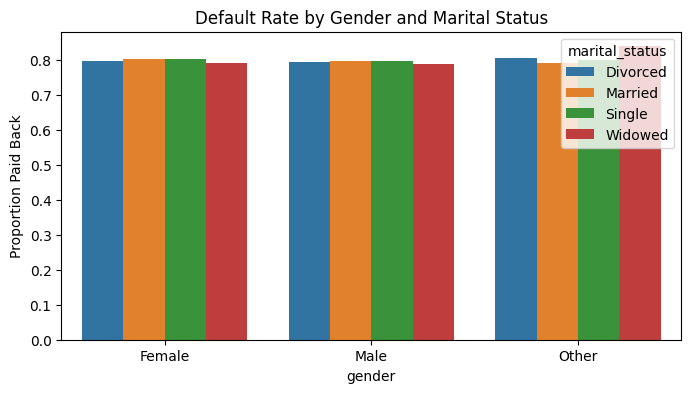

In [22]:
# Marriage and Gender combination
df = train.copy()
df['gender_marital'] = df['gender'] + '_' + df['marital_status']
df['education_employment'] = df['education_level'] + '_' + df['employment_status']

combo = df.groupby(['gender', 'marital_status'])['loan_paid_back'].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=combo, x='gender', y='loan_paid_back', hue='marital_status')
plt.title("Default Rate by Gender and Marital Status")
plt.ylabel("Proportion Paid Back")
plt.show()

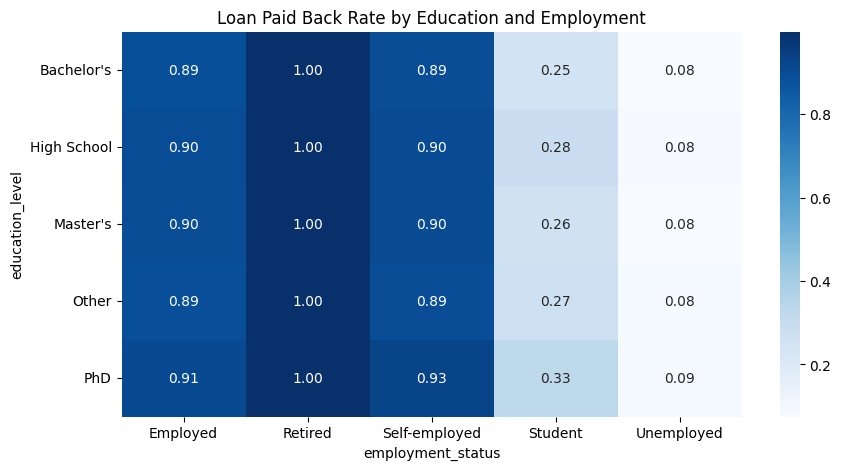

In [23]:
# Education and employment status
combo2 = df.groupby(['education_level', 'employment_status'])['loan_paid_back'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.heatmap(combo2.pivot(index = 'education_level', columns = 'employment_status', values = 'loan_paid_back'),
            annot=True, cmap='Blues', fmt='.2f')
plt.title("Loan Paid Back Rate by Education and Employment")
plt.show()

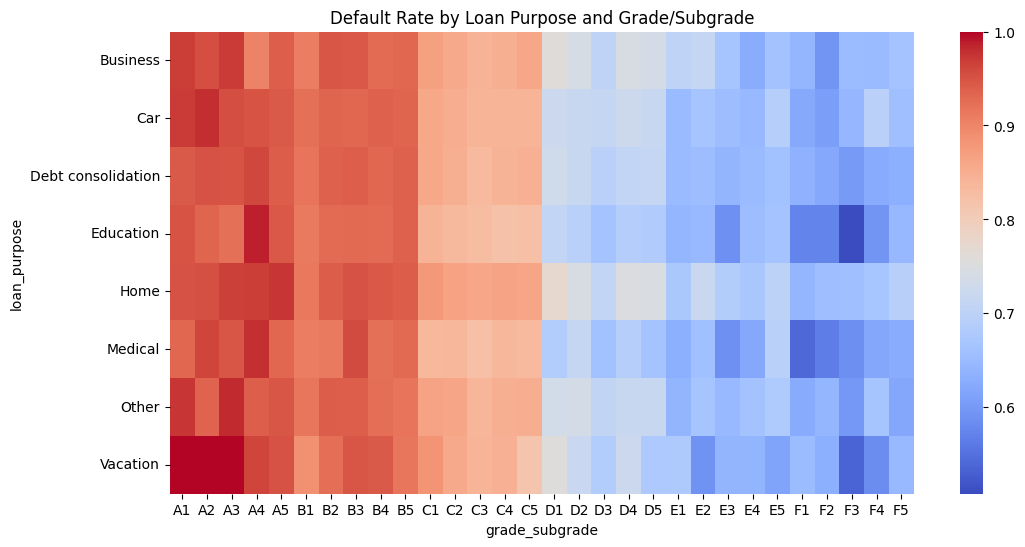

In [24]:
combo3 = df.groupby(['loan_purpose', 'grade_subgrade'])['loan_paid_back'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.heatmap(combo3.pivot(index = 'loan_purpose', columns = 'grade_subgrade', values = 'loan_paid_back'),
            annot=False, cmap='coolwarm')
plt.title("Default Rate by Loan Purpose and Grade/Subgrade")
plt.show()


In [25]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['gender_marital'], df['loan_paid_back'])
chi2, p, dof, ex = chi2_contingency(ct)
print(f"For gender_marital: Chi2 = {chi2:.2f}, p = {p:.4f}")

ct = pd.crosstab(df['grade_subgrade'], df['loan_paid_back'])
chi2, p, dof, ex = chi2_contingency(ct)
print(f"For grade_subgrade: Chi2 = {chi2:.2f}, p = {p:.4f}")

ct = pd.crosstab(df['education_employment'], df['loan_paid_back'])
chi2, p, dof, ex = chi2_contingency(ct)
print(f"For education_employment: Chi2 = {chi2:.2f}, p = {p:.4f}")


For gender_marital: Chi2 = 38.92, p = 0.0001
For grade_subgrade: Chi2 = 30871.16, p = 0.0000
For education_employment: Chi2 = 256356.18, p = 0.0000


🔢 4️⃣ Chi-square Significance Overview
| Feature Combination  | χ² Value  | p-value | Strength         | Interpretation                                  |
| -------------------- | --------- | ------- | ---------------- | ----------------------------------------------- |
| gender_marital       | 38.92     | 0.0001  | 🔹 Weak–Moderate | Statistically significant but effect size small |
| grade_subgrade       | 30871.16  | <0.0001 | 🔸 Strong        | Extremely predictive of loan repayment          |
| education_employment | 256356.18 | <0.0001 | 🔥 Very Strong   | Strong dependence — major driver of repayment   |


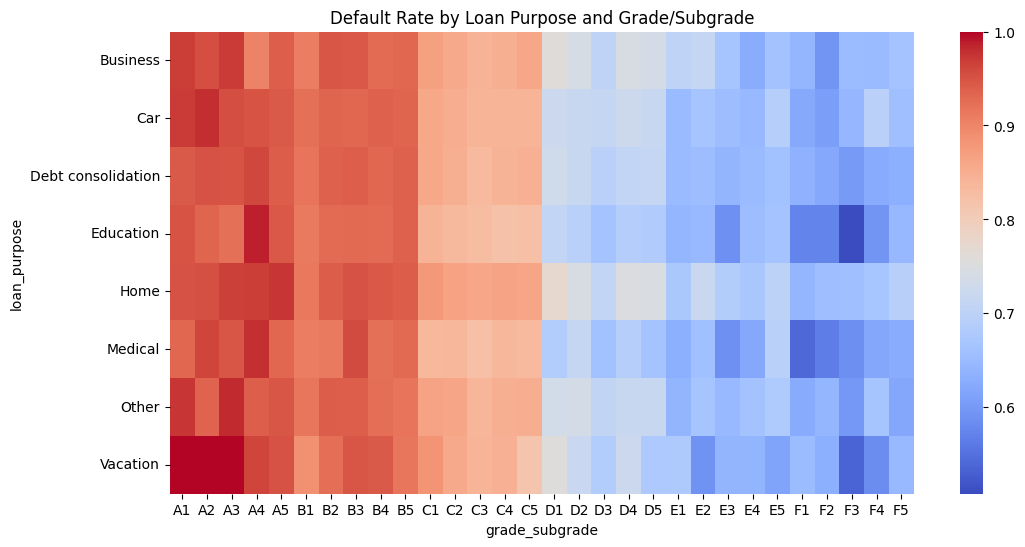

In [26]:
df["grade_purpose"] = df["grade_subgrade"] + '_' + df["loan_purpose"]
combo4 = df.groupby(['loan_purpose', 'grade_subgrade'])['loan_paid_back'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.heatmap(combo3.pivot(index = 'loan_purpose', columns = 'grade_subgrade', values = 'loan_paid_back'),
            annot=False, cmap='coolwarm')
plt.title("Default Rate by Loan Purpose and Grade/Subgrade")
plt.show()


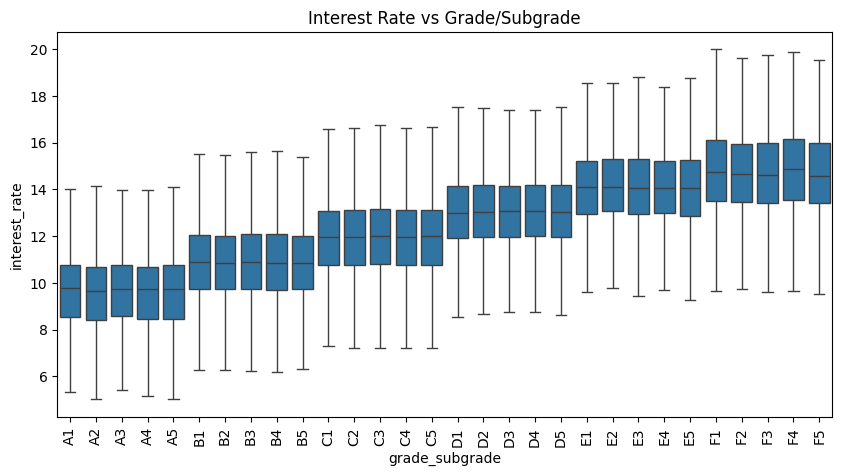

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(data=train.sort_values(by="grade_subgrade"), x='grade_subgrade', y='interest_rate', showfliers=False)
plt.xticks(rotation=90)
plt.title("Interest Rate vs Grade/Subgrade")
plt.show()

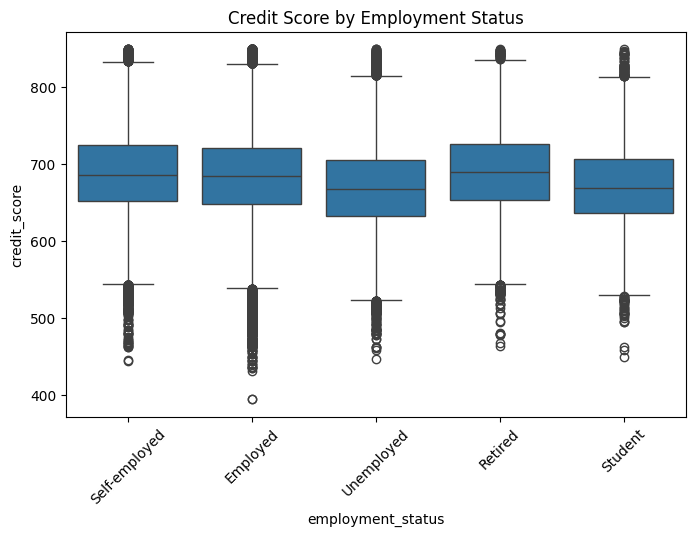

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='employment_status', y='credit_score')
plt.title("Credit Score by Employment Status")
plt.xticks(rotation=45)
plt.show()


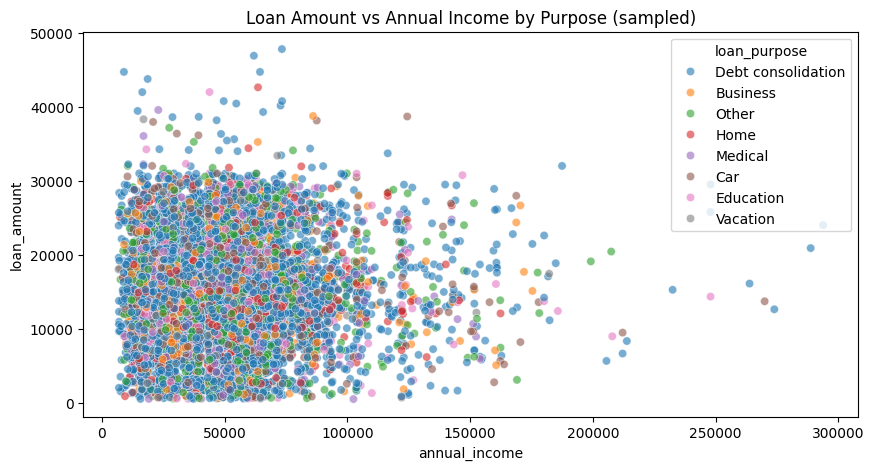

In [29]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=train.sample(10000), 
    x='annual_income', 
    y='loan_amount', 
    hue='loan_purpose', 
    alpha=0.6
)
plt.title("Loan Amount vs Annual Income by Purpose (sampled)")
plt.show()


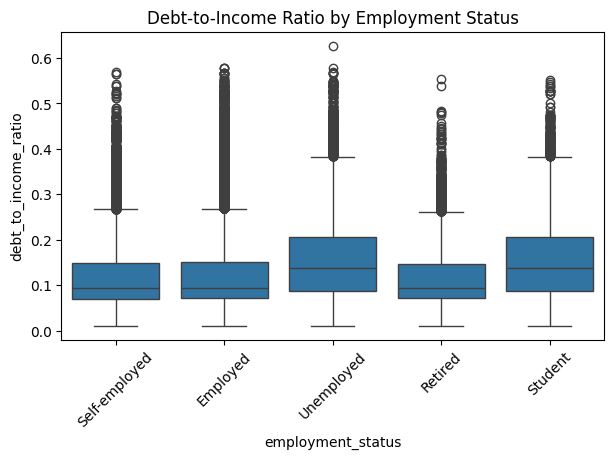

In [30]:
plt.figure(figsize=(7,4))
sns.boxplot(data=train, x='employment_status', y='debt_to_income_ratio')
plt.title("Debt-to-Income Ratio by Employment Status")
plt.xticks(rotation=45)
plt.show()


C:\Users\16yas\AppData\Local\Temp\ipykernel_13932\4271979223.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_default = train.groupby('credit_bin')['loan_paid_back'].mean()
C:\Users\16yas\AppData\Local\Temp\ipykernel_13932\4271979223.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_default = train.groupby('rate_bin')['loan_paid_back'].mean()


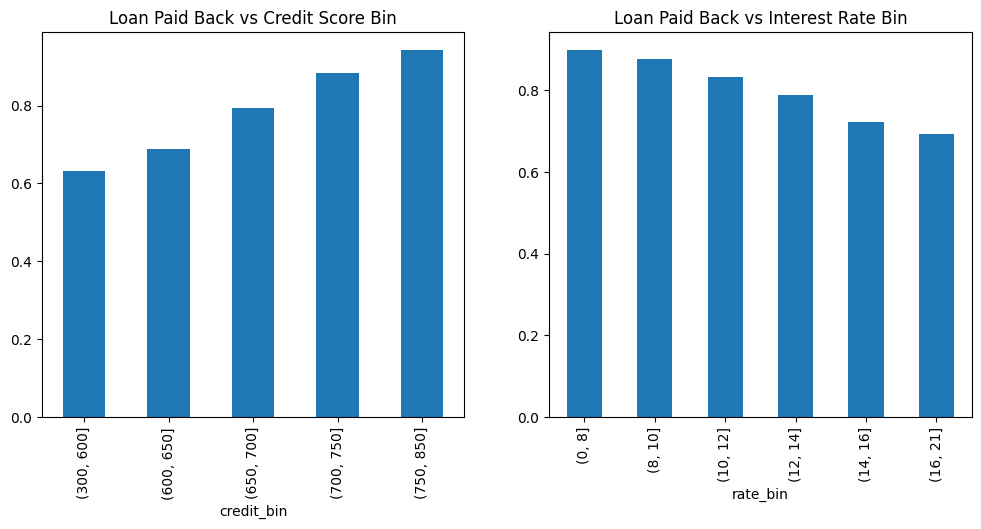

In [31]:
train['credit_bin'] = pd.cut(train['credit_score'], bins=[300,600,650,700,750,850])
credit_default = train.groupby('credit_bin')['loan_paid_back'].mean()

train['rate_bin'] = pd.cut(train['interest_rate'], bins=[0,8,10,12,14,16,21])
rate_default = train.groupby('rate_bin')['loan_paid_back'].mean()

fig, ax = plt.subplots(1,2, figsize=(12,5))
credit_default.plot(kind='bar', ax=ax[0], title='Loan Paid Back vs Credit Score Bin')
rate_default.plot(kind='bar', ax=ax[1], title='Loan Paid Back vs Interest Rate Bin')
plt.show()


C:\Users\16yas\AppData\Local\Temp\ipykernel_13932\2673280172.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = heat.pivot_table(index='credit_bin', columns='rate_bin', values='loan_paid_back')


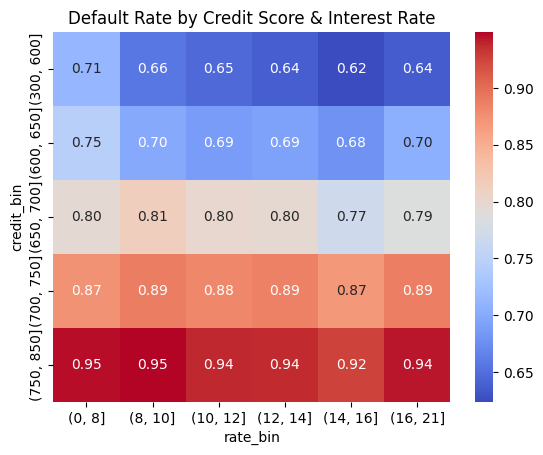

In [32]:
heat = train.copy()
heat['credit_bin'] = pd.cut(heat['credit_score'], bins=[300,600,650,700,750,850])
heat['rate_bin'] = pd.cut(heat['interest_rate'], bins=[0,8,10,12,14,16,21])
pivot = heat.pivot_table(index='credit_bin', columns='rate_bin', values='loan_paid_back')
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Default Rate by Credit Score & Interest Rate")
plt.show()


In [34]:
from scipy.stats import pointbiserialr

for col in ['annual_income','debt_to_income_ratio','credit_score','loan_amount','interest_rate']:
    corr, p = pointbiserialr(train[col], train['loan_paid_back'])
    print(f"{col}: corr={corr:.3f}, p={p:.4f}")


annual_income: corr=0.006, p=0.0000
debt_to_income_ratio: corr=-0.336, p=0.0000
credit_score: corr=0.235, p=0.0000
loan_amount: corr=-0.004, p=0.0037
interest_rate: corr=-0.131, p=0.0000


In [35]:
train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,credit_bin,rate_bin
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,"(700, 750]","(12, 14]"
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,"(600, 650]","(12, 14]"
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,"(650, 700]","(8, 10]"
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,"(300, 600]","(16, 21]"
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,"(650, 700]","(10, 12]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0,"(700, 750]","(10, 12]"
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0,"(300, 600]","(14, 16]"
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0,"(650, 700]","(14, 16]"
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0,"(700, 750]","(8, 10]"


In [45]:
pd.read_csv(r'../playground-series-s5e11/train.csv')

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ==================================================
# 1️⃣ Load dataset
# ==================================================
data = pd.read_csv(r'../playground-series-s5e11/train.csv')
def preprocessing(data, is_test=False):
    # ==================================================
    # 2️⃣ Numerical Transformations
    # ==================================================
    for col in ['annual_income', 'loan_amount']:
        data[col] = np.log1p(data[col])  # safe log transform

    # Winsorize DTI
    data['debt_to_income_ratio'] = np.clip(data['debt_to_income_ratio'], 0, 1)

    # ==================================================
    # 3️⃣ Encode grade/subgrade to ordinal numeric
    # ==================================================
    grade_order = sorted(data['grade_subgrade'].dropna().unique(), key=lambda x: (x[0], int(x[1])))
    grade_map = {grade: i + 1 for i, grade in enumerate(grade_order)}
    data['grade_numeric'] = data['grade_subgrade'].map(grade_map)

    # ==================================================
    # 4️⃣ Derived / Composite Features
    # ==================================================
    data['loan_to_income_ratio'] = data['loan_amount'] / data['annual_income']
    data['income_to_loan_ratio'] = data['annual_income'] / data['loan_amount']
    data['credit_to_income_ratio'] = data['credit_score'] / data['annual_income']
    data['interest_per_credit'] = data['interest_rate'] / data['credit_score']
    data['dti_x_interest'] = data['debt_to_income_ratio'] * data['interest_rate']

    # ==================================================
    # 5️⃣ Interaction Features
    # ==================================================
    data['income_rate_ratio'] = data['annual_income'] / (data['interest_rate'] + 1)
    data['loan_credit_interaction'] = data['loan_amount'] * data['credit_score']

    # ==================================================
    # 6️⃣ Define Feature Sets
    # ==================================================
    num_features = [
        'credit_score', 'annual_income', 'loan_amount', 'debt_to_income_ratio',
        'interest_rate', 'loan_to_income_ratio', 'income_to_loan_ratio',
        'credit_to_income_ratio', 'interest_per_credit', 'dti_x_interest',
        'income_rate_ratio', 'loan_credit_interaction', 'grade_numeric'
    ]

    cat_features = [
        'employment_status', 'loan_purpose', 'marital_status',
        'gender', 'education_level'
    ]

    # Target column
    target = 'loan_paid_back'

    # ==================================================
    # 7️⃣ Preprocessing Pipelines
    # ==================================================
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_features),
            ('cat', cat_transformer, cat_features)
        ]
    )

    # ==================================================
    # 8️⃣ Fit-transform (exclude ID, target)
    # ==================================================
    X = data[num_features + cat_features]
    if not is_test:
        y = data[target]

    X_processed = preprocessor.fit_transform(X)

    # ==================================================
    # 9️⃣ Retrieve feature names
    # ==================================================
    num_cols = num_features
    cat_cols = list(
        preprocessor.named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(cat_features)
    )

    all_feature_names = num_cols + cat_cols

    # Convert to DataFrame
    processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

    # Add target & ID back
    processed_df['id'] = data['id'].values
    if not is_test:
        processed_df['loan_paid_back'] = y.values

    # ==================================================
    # 🔎 Inspect
    # ==================================================
    print("✅ Feature engineering complete!")
    print(f"Total features created: {processed_df.shape[1]}")
    processed_df.head(3)
    return processed_df, all_feature_names


In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert preprocessed data (numeric only) to DataFrame first
numeric_df = pd.DataFrame(
    preprocessor.named_transformers_['num']
    .named_steps['scaler']
    .transform(
        data[num_features].fillna(data[num_features].median())
    ),
    columns=num_features
)

# === 1️⃣ Correlation-based filtering ===
corr_matrix = numeric_df.corr().abs()

# upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features with correlation > 0.9
high_corr_features = [column for column in upper.columns if any(upper[column] > 0.9)]
print(f"🔸 Highly correlated (>0.9) features to drop: {high_corr_features}")

numeric_df.drop(columns=high_corr_features, inplace=True)
num_features = [f for f in num_features if f not in high_corr_features]

# === 2️⃣ VIF-based filtering ===
def calculate_vif(df):
    vif = pd.DataFrame()
    vif["feature"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

vif_df = calculate_vif(numeric_df)
print("🔹 Initial VIFs:\n", vif_df)

# Drop features with VIF > 10
while vif_df['VIF'].max() > 10:
    drop_feat = vif_df.loc[vif_df['VIF'].idxmax(), 'feature']
    print(f"🚫 Dropping {drop_feat} (VIF={vif_df['VIF'].max():.2f})")
    numeric_df.drop(columns=[drop_feat], inplace=True)
    vif_df = calculate_vif(numeric_df)

print("✅ Remaining numeric features after VIF filtering:")
print(list(numeric_df.columns))


d:\Dsoft\Projects\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


🔸 Highly correlated (>0.9) features to drop: ['income_to_loan_ratio', 'interest_per_credit', 'dti_x_interest', 'income_rate_ratio']
🔹 Initial VIFs:
                    feature         VIF
0             credit_score  461.313696
1            annual_income  125.618424
2              loan_amount  361.778908
3     debt_to_income_ratio    1.003990
4            interest_rate    1.408216
5     loan_to_income_ratio  344.050451
6   credit_to_income_ratio  360.408282
7  loan_credit_interaction  361.950461
🚫 Dropping credit_score (VIF=461.31)
🚫 Dropping loan_amount (VIF=352.20)
🚫 Dropping annual_income (VIF=93.98)
✅ Remaining numeric features after VIF filtering:
['debt_to_income_ratio', 'interest_rate', 'loan_to_income_ratio', 'credit_to_income_ratio', 'loan_credit_interaction']


Class distribution:
 loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

Class ratio: 0.2518


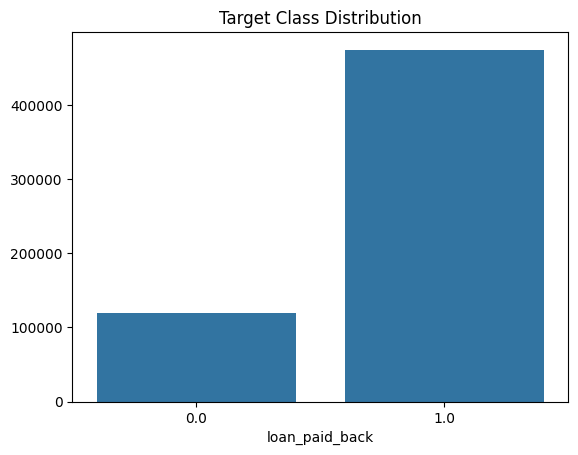

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your target column name
target_col = 'loan_paid_back'

class_counts = df[target_col].value_counts()
print("Class distribution:\n", class_counts)
print("\nClass ratio:", round(class_counts.min() / class_counts.max(), 4))

sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Target Class Distribution")
plt.show()


In [2]:
processed_df

NameError: name 'processed_df' is not defined

✅ Feature engineering complete!
Total features created: 40
✅ Feature engineering complete!
Total features created: 39
--- Fold 1/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.9226652056992015
              precision    recall  f1-score   support

         0.0       0.64      0.79      0.71     23900
         1.0       0.94      0.89      0.92     94899

    accuracy                           0.87    118799
   macro avg       0.79      0.84      0.81    118799
weighted avg       0.88      0.87      0.87    118799

[[18904  4996]
 [10605 84294]]
[0]	validation_0-auc:0.90611
[722]	validation_0-auc:0.92201

🔹 XGBoost Performance:
ROC-AUC: 0.9220743346119002
              precision    recall  f1-score   support

         0.0       0.64      0.79      0.71     23900
         1.0       0.94      0.89      0.92     94899

    accuracy                           0.87    118799
   macro avg       0.79      0.84      0.81    118799
weighted avg       0.88      0.87      0.87    118799

[[18864  5036]


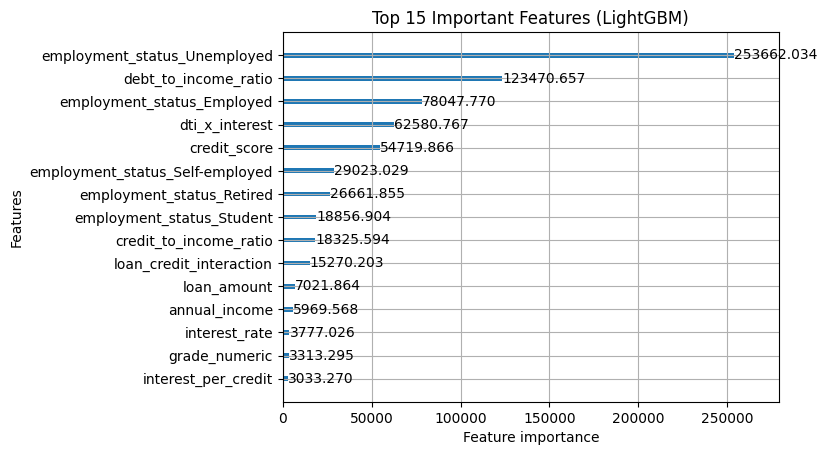

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

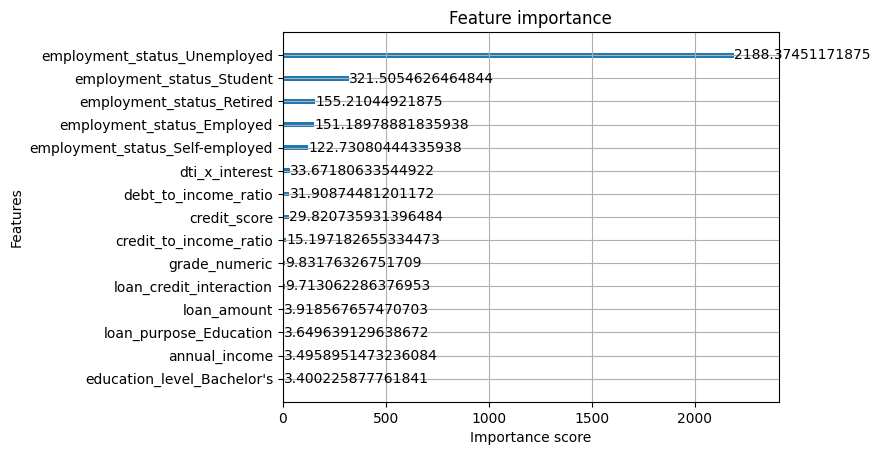

In [33]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

oof_preds_lgb = np.zeros(len(X))
oof_preds_xgb = np.zeros(len(X))

processed_df, all_cols = preprocessing(data=train_org)
processed_test = preprocessing(test_org, True)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=0.2, random_state=42, stratify=y
    # )

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/3.9706515242080096,
        n_jobs=-1,
        early_stopping_rounds=50,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )

    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))
    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))

    # ----------------------------------------------------------
    # ⚡ Option 2: XGBoost
    # ----------------------------------------------------------
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=1/3.9706515242080096,
        early_stopping_rounds=50,
        eval_metric='auc',
        enable_categorical=True
    )

    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=1000
    )

    y_pred_xgb = xgb_model.predict(X_test)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

    print("\n🔹 XGBoost Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
    print(classification_report(y_test, y_pred_xgb))
    oof_preds_xgb[val_idx] = xgb_model.predict_proba(X_test, iteration_range=[0,xgb_model.best_iteration])[:, 1]
    print(confusion_matrix(y_test, (y_pred_xgb > 0.5).astype(int)))

print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


✅ Feature engineering complete!
Total features created: 40
✅ Feature engineering complete!
Total features created: 39
--- Fold 1/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.9228177700132283
              precision    recall  f1-score   support

         0.0       0.73      0.74      0.73     23900
         1.0       0.93      0.93      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.83      0.84      0.83    118799
weighted avg       0.89      0.89      0.89    118799

[[17669  6231]
 [ 6573 88326]]
--- Fold 2/5 ---

🔹 LightGBM Performance:
ROC-AUC: 0.9225247696725447
              precision    recall  f1-score   support

         0.0       0.73      0.74      0.73     23900
         1.0       0.93      0.93      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.83      0.83      0.83    118799
weighted avg       0.89      0.89      0.89    118799

[[17619  6281]
 [ 6503 88396]]
--- Fold 3/5 ---

🔹 LightG

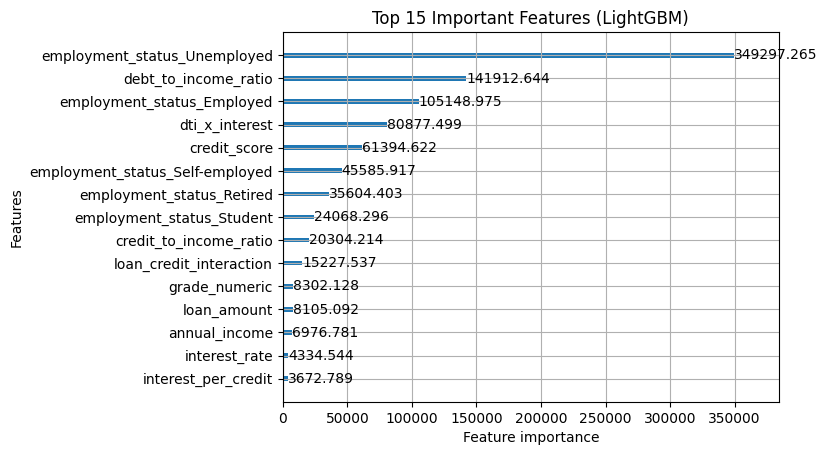

In [34]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

skf = StratifiedKFold(random_state=42, shuffle=True, n_splits=5)

oof_preds_lgb = np.zeros(len(X))
oof_preds_xgb = np.zeros(len(X))

processed_df, all_cols = preprocessing(data=train_org)
processed_test = preprocessing(test_org, True)

# 🧩 Step 1: Split data
X = processed_df.drop('loan_paid_back', axis=1)  # replace with your target column
X = X.drop('id', axis=1)  # replace with your target column
y = processed_df['loan_paid_back']

X[all_cols] = X[all_cols].astype('float64')
# X[cat_cols] = X[cat_cols].astype('category')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{5} ---')

    X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    # X_train, X_test, y_train, y_test = train_test_split(
    #     X, y, test_size=0.2, random_state=42, stratify=y
    # )

    # ----------------------------------------------------------
    # ⚡ Option 1: LightGBM
    # ----------------------------------------------------------
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        reg_lambda=0,
        reg_alpha=0.5,
        subsample=0.8,
        min_child_samples=75,
        colsample_bytree=0.6,
        random_state=42,
        scale_pos_weight=1/2.5,
        n_jobs=-1,
        early_stopping_rounds=50,
        verbose=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc'
    )

    y_pred_lgb = lgb_model.predict(X_test)
    y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

    print("\n🔹 LightGBM Performance:")
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_lgb))
    oof_preds_lgb[val_idx] = lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]
    print(classification_report(y_test, y_pred_lgb))
    print(confusion_matrix(y_test, (y_pred_lgb > 0.5).astype(int)))

    # ----------------------------------------------------------
    # ⚡ Option 2: XGBoost
    # ----------------------------------------------------------
    # xgb_model = xgb.XGBClassifier(
    #     objective='binary:logistic',
    #     n_estimators=1000,
    #     learning_rate=0.05,
    #     max_depth=6,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     random_state=42,
    #     n_jobs=-1,
    #     scale_pos_weight=1/3.9706515242080096,
    #     early_stopping_rounds=50,
    #     eval_metric='auc',
    #     enable_categorical=True
    # )

    # xgb_model.fit(
    #     X_train, y_train,
    #     eval_set=[(X_test, y_test)],
    #     verbose=1000
    # )

    # y_pred_xgb = xgb_model.predict(X_test)
    # y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

    # print("\n🔹 XGBoost Performance:")
    # print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
    # print(classification_report(y_test, y_pred_xgb))
    # oof_preds_xgb[val_idx] = xgb_model.predict_proba(X_test, iteration_range=[0,xgb_model.best_iteration])[:, 1]
    # print(confusion_matrix(y_test, (y_pred_xgb > 0.5).astype(int)))

print("OOF AUC: LGBM:", roc_auc_score(y, oof_preds_lgb))
# print("OOF AUC: XGB", roc_auc_score(y, oof_preds_xgb))


# ----------------------------------------------------------
# 🔍 Feature Importance (example for LightGBM)
# ----------------------------------------------------------
import matplotlib.pyplot as plt

lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Important Features (LightGBM)")
plt.show()

# xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')


In [55]:
X[cat_cols].value_counts()

employment_status_Employed  employment_status_Retired  employment_status_Self-employed  employment_status_Student  employment_status_Unemployed  loan_purpose_Business  loan_purpose_Car  loan_purpose_Debt consolidation  loan_purpose_Education  loan_purpose_Home  loan_purpose_Medical  loan_purpose_Other  loan_purpose_Vacation  marital_status_Divorced  marital_status_Married  marital_status_Single  marital_status_Widowed  gender_Female  gender_Male  gender_Other  education_level_Bachelor's  education_level_High School  education_level_Master's  education_level_Other  education_level_PhD
1.0                         0.0                        0.0                              0.0                        0.0                           0.0                    0.0               1.0                              0.0                     0.0                0.0                   0.0                 0.0                    0.0                      0.0                     1.0                    0.0       

In [22]:
print(xgb.__version__)

3.1.1
